In [1]:
import pandas as pd
data_url = 'https://docs.google.com/spreadsheets/d/1g0mjTUZ9Ado5prXA1UnAvNjmdzTrV0TzkFkIoU-Lpbk/export?format=csv'
df = pd.read_csv(data_url)
display(df.head())

,Examination 1 Score,Examination 2 Score,Admission Status (0 for Not Admitted and 1 for Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [2]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Examination 1 Score                                      100 non-null    float64
 1   Examination 2 Score                                      100 non-null    float64
 2   Admission Status (0 for Not Admitted and 1 for Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


None

,Examination 1 Score,Examination 2 Score,Admission Status (0 for Not Admitted and 1 for Admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [3]:
df.rename(columns={'Admission Status (0 for Not Admitted and 1 for Admitted': 'Admission_Status'}, inplace=True)
print(df.columns)

Index(['Examination 1 Score', 'Examination 2 Score', 'Admission_Status'], dtype='object')


## Data Visualization

Let's visualize the data to understand the distribution of examination scores and how they relate to admission status. A scatter plot will be useful to see if there's a clear separation between admitted and not-admitted students.

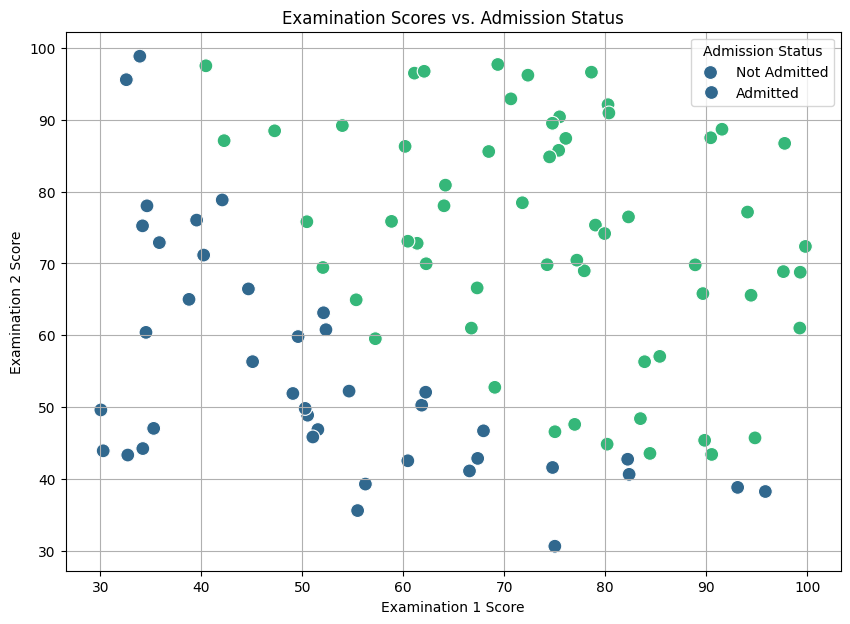

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Examination 1 Score',
    y='Examination 2 Score',
    hue='Admission_Status',
    data=df,
    palette='viridis',
    s=100
)
plt.title('Examination Scores vs. Admission Status')
plt.xlabel('Examination 1 Score')
plt.ylabel('Examination 2 Score')
plt.legend(title='Admission Status', loc='upper right', labels=['Not Admitted', 'Admitted'])
plt.grid(True)
plt.show()

## Data Preparation for Modeling

Before training a classification model, we need to split the dataset into features (X) and the target variable (y). Then, we will divide the data into training and testing sets to evaluate the model's performance on unseen data.

In [5]:
from sklearn.model_selection import train_test_split
X = df[['Examination 1 Score', 'Examination 2 Score']]
y = df['Admission_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80, 2)
y_train shape: (80,)
X_test shape: (20, 2)
y_test shape: (20,)


## Model Training and Evaluation

We will use Logistic Regression as our classification model. After training, we'll evaluate its performance on the test set using accuracy and a classification report.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



## Visualizing the Decision Boundary

To better understand how our Logistic Regression model is classifying students, let's visualize its decision boundary on the scatter plot of examination scores. This will show us the line that the model uses to separate the two classes (admitted vs. not admitted).

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


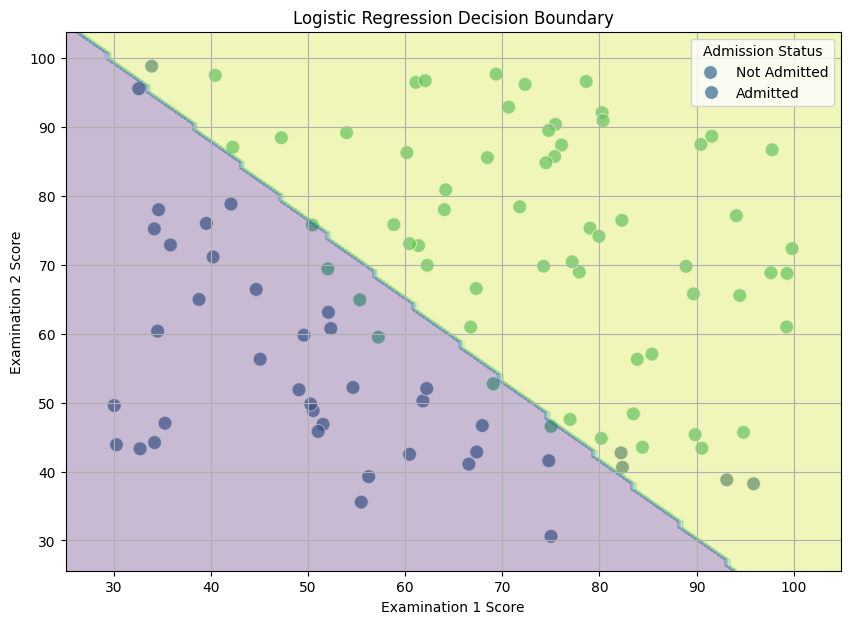

In [7]:
import numpy as np
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Examination 1 Score',
    y='Examination 2 Score',
    hue='Admission_Status',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.7
)
x_min, x_max = X['Examination 1 Score'].min() - 5, X['Examination 1 Score'].max() + 5
y_min, y_max = X['Examination 2 Score'].min() - 5, X['Examination 2 Score'].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Examination 1 Score')
plt.ylabel('Examination 2 Score')
plt.legend(title='Admission Status', loc='upper right', labels=['Not Admitted', 'Admitted'])
plt.grid(True)
plt.show()